# From FNN to RNN — Why Sequence Architecture Matters

## The Problem with FNN on Sequential Data

A FNN takes a flat vector as input. To use past information, you manually build a window of lagged returns:
```python
input = [return_t-5, return_t-4, return_t-3, return_t-2, return_t-1]  →  predict volatility_t
```

This works, but has three fundamental limitations.

---

## Limitation 1 — Order Blindness

The FNN assigns an independent weight to each lag. It has no built-in understanding that lag 1 and lag 2 are neighbors in time, or that one happened before the other. The temporal ordering only exists because you constructed the vector that way.

**Proof:** shuffle the elements of the input vector randomly — the FNN produces nearly identical results. An RNN would break completely.

---

## Limitation 2 — Fixed Hard Cutoff

You must decide upfront how many lags to include. If volatility clustering from 45 days ago is relevant today, a window of 30 days will never capture it — no matter how well you train the model.

---

## Limitation 3 — Parameter Explosion

Every extra lag adds a full set of input weights. With 60 days and 5 features, the first layer already has 300 weights just for the inputs. Doubling the window doubles the parameters.

---

## What the RNN Changes

Instead of consuming a flat vector, the RNN processes one time step at a time and maintains a **hidden state** — a compressed memory of everything seen so far.

The same weight matrix is reused at every step — so the number of parameters does not grow with sequence length.

---

## Why This Matters for Volatility Forecasting

Volatility clustering means high volatility today predicts high volatility tomorrow — and this effect can persist for **weeks or months**. A FNN with a 10-day window is structurally blind to anything beyond day 10.

The RNN hidden state accumulates this context automatically. A spike 3 weeks ago influences h_t-20, which flows into h_t-19, all the way to today's prediction. The network decides what to keep and what to forget — rather than you deciding upfront with a fixed window.

---

## What RNN Does Not Solve — The Vanishing Gradient

In practice the hidden state cannot carry information indefinitely. During backpropagation through many time steps, gradients shrink exponentially — the network effectively forgets anything beyond ~10-20 steps. This is the **vanishing gradient problem**, and it is the motivation for the LSTM.

In [4]:
import torch
import torch.nn as nn
import sys
sys.path.append('src')
from data_utils import *
from dl_utils.Operation import WeightMultiply
from dl_utils.NumberWithGrad import NumberWithGrad
from sklearn.model_selection import train_test_split
from dl_utils.Rnn import *
import pandas as pd
from model_analysis.Rnn_analysis import *
from copy import deepcopy

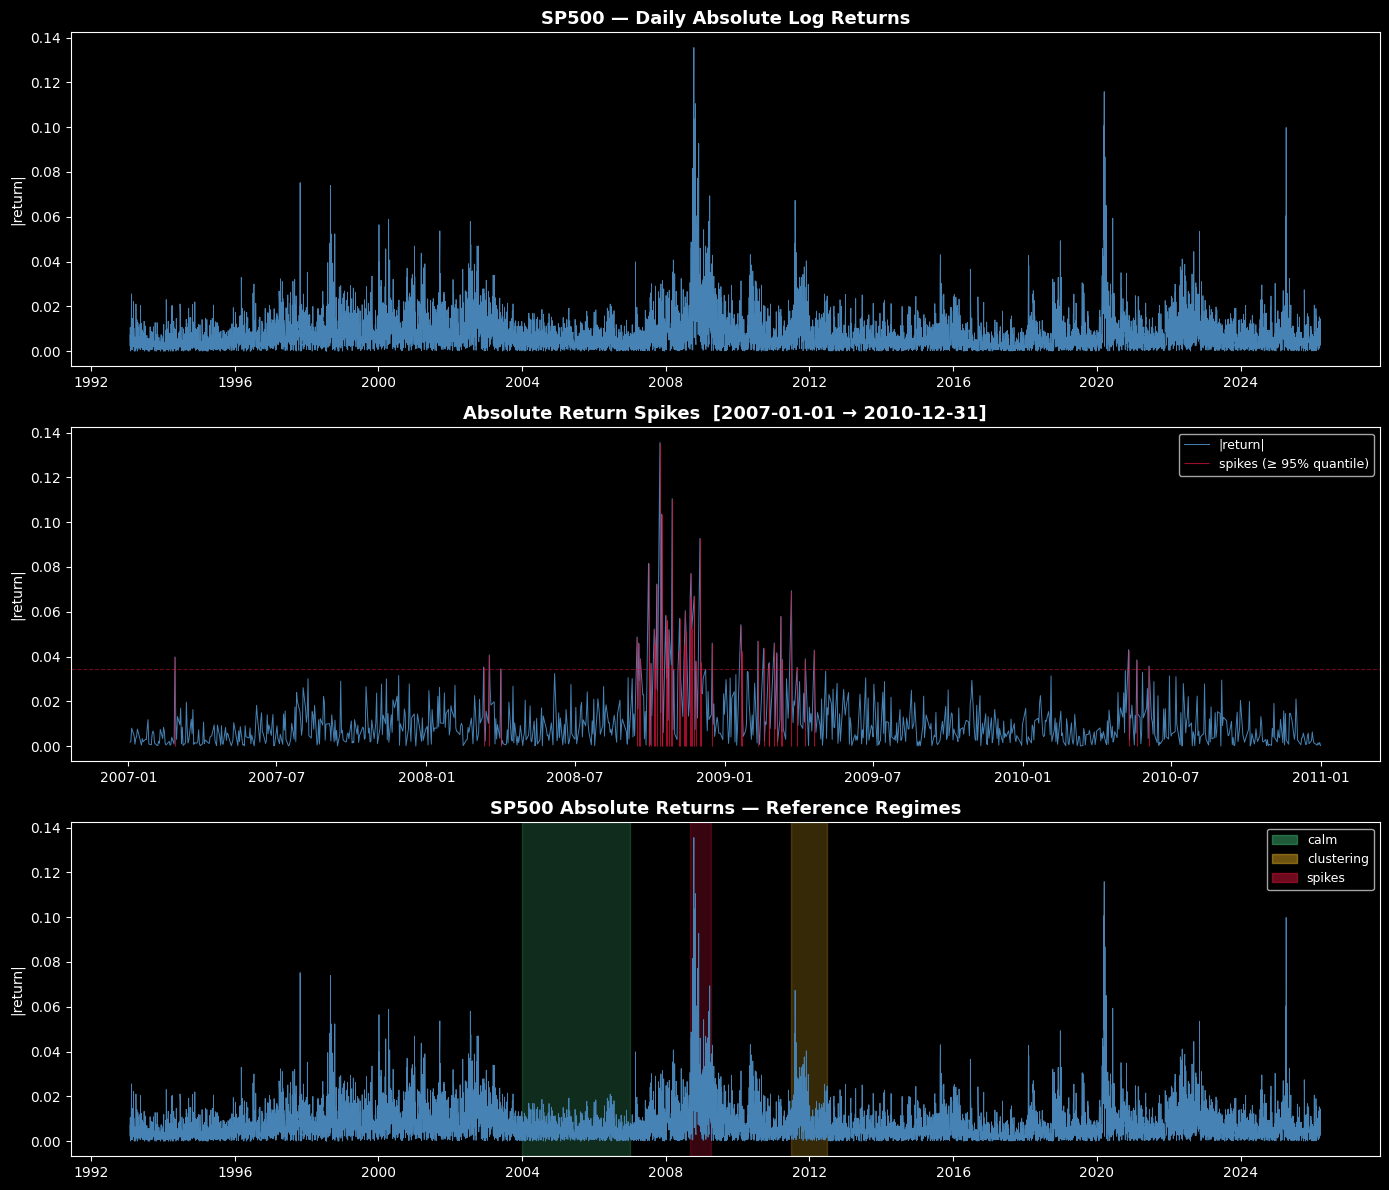

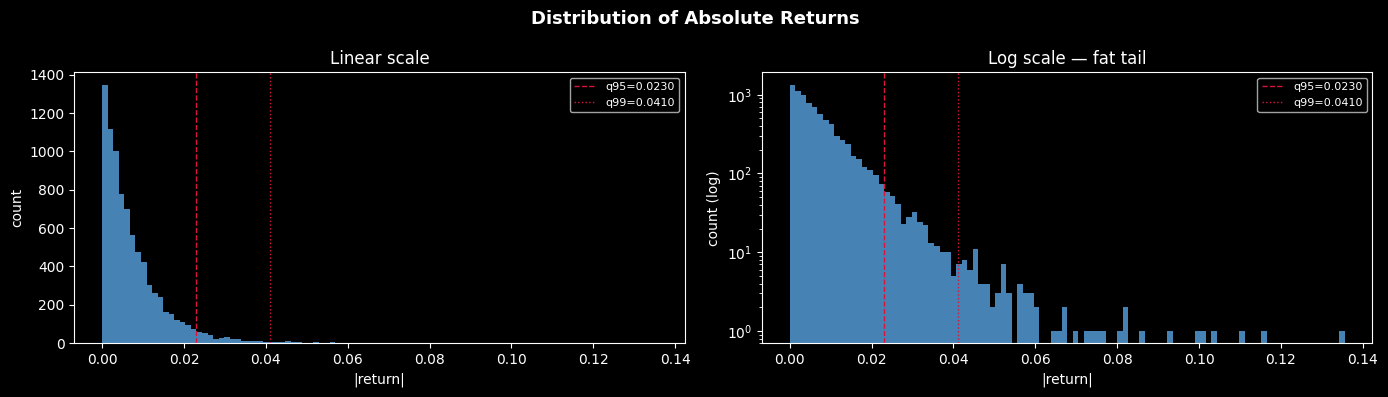

test_df: 545 rows across 3 regimes
  calm         2017-01-01 → 2017-12-31  (251 rows)
  clustering   2022-01-01 → 2022-12-31  (251 rows)
  spikes       2020-03-01 → 2020-04-30  (43 rows)
train_df: 7798 rows  (removed 545 test rows)
X_train: (6222, 20, 1)  X_val: (1556, 20, 1)
  calm          X: (231, 20, 1)
  clustering    X: (231, 20, 1)
  spikes        X: (23, 20, 1)


In [5]:
path_data = r"./data/df_sp_500_log_ret.csv"
df = pd.read_csv(path_data, index_col= "Date")
SEQUENCE_LENGTH = 20
plot_data_overview(df)
plot_abs_return_distribution(df) 
test_df = build_test_df(df, sequence_length=SEQUENCE_LENGTH)
X_train, y_train, X_val, y_val, regime_sets, scaler_X, scaler_y = prepare_datasets(df, test_df, sequence_length=SEQUENCE_LENGTH, test_size=0.2)
   

## Regime-Aware Test Set

The standard train/test split gives a single aggregate MAE — useful, but it hides where the model actually fails. A model can look decent on average while being completely wrong on the days that matter most (spikes, crisis periods).

To get a clearer picture, we isolate three post-2017 periods that were **never seen during training**, each representing a structurally different market regime:

| Regime | Period | Characteristic |
|--------|--------|----------------|
| **Calm** | 2017 | Small, stable daily moves — the easiest regime |
| **Clustering** | 2022 | Persistently elevated moves over a full year (Fed rate hike cycle) |
| **Spikes** | Mar–Apr 2020 | Extreme isolated moves (COVID crash) — never seen in training |

These three regimes are plotted below against the full series (greyed out).

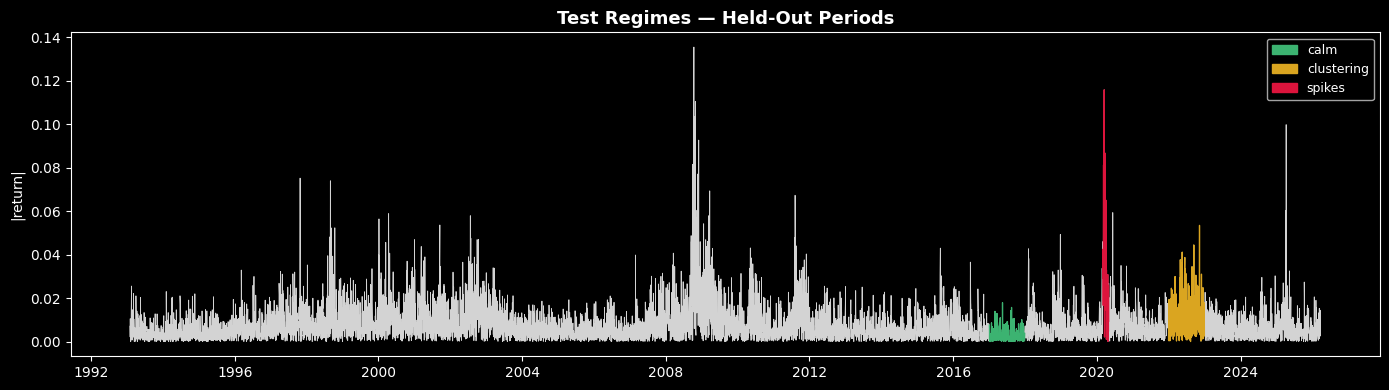

In [6]:
plot_test_regimes(df, test_df)

# Baseline RNN — Architecture 1

## Architecture

A minimal RNN with a single recurrent layer and one linear output head. This is intentionally the simplest possible configuration — it serves as the reference point against which all other architectures will be compared.

#

In [7]:
from sklearn.metrics import mean_absolute_error
INPUT_SIZE = X_train.shape[2]
OUTPUT_SIZE = y_train.shape[-1]

HIDDEN_SIZE = 64
NUM_LAYER = 1
NODE_ACTIVATION = "tanh"
DROPOUT = 0.0
BIDIRECTIONAL = False

HEAD_ACTIVATION = "none"   # linear output — required for regression
HEAD_DROPOUT = 0.0
HEAD_WEIGHT_INIT = 'xavier_uniform'
HEAD_BIAS_INIT = "zeros"

nn_head_1 = Dense(HIDDEN_SIZE, OUTPUT_SIZE,
                  HEAD_ACTIVATION, HEAD_DROPOUT,
                  True, HEAD_WEIGHT_INIT, HEAD_BIAS_INIT, False)

Rnn_simple = RNN(input_size=INPUT_SIZE,
                 hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYER,
                 nonlinearity=NODE_ACTIVATION,
                 rnn_dropout=DROPOUT,
                 bidirectional=BIDIRECTIONAL,
                 head=[nn_head_1])

Rnn_before =  deepcopy(Rnn_simple)
LOSS = 'mse'
OPTIMIZER = "adam"
LR = 0.0005
BATCH_SIZE = 32
N_EPOCH = 200
SHUFFLE = True
GRADIENT_CLIPPING = 0.5
EARLY_STOPPING = 30
VERBOSE = 10

trainer = Trainer(Rnn_simple, LOSS, OPTIMIZER, LR, BATCH_SIZE,
                  N_EPOCH, SHUFFLE, GRADIENT_CLIPPING, EARLY_STOPPING, VERBOSE)
trainer.fit(X_train, y_train, X_val, y_val)

# always: predict in scaled space → inverse_transform explicitly
y_pred    = scaler_y.inverse_transform(trainer.predict(X_val).reshape(-1, 1))
y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1, 1))
print(f"MAE: {mean_absolute_error(y_val_inv, y_pred):.5f}")

epoch    0  train: 0.930737  test: 0.557945
epoch   10  train: 0.737417  test: 0.686929
epoch   20  train: 0.742172  test: 0.588734
epoch   30  train: 0.724907  test: 0.615300
epoch   40  train: 0.696839  test: 0.557090
early stopping at epoch 44 — best test loss: 0.541466
MAE: 0.00436


### Validation Set — Predicted vs True Distribution

Before looking at regimes, check whether the model has learned the right overall shape. If the predicted distribution is much narrower than the true one, the model is regressing toward the mean and missing extremes.

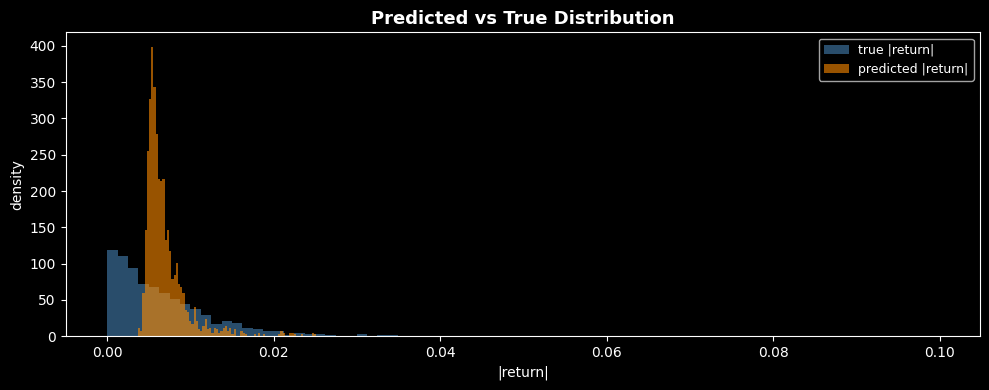

In [8]:
plot_pred_vs_true_distribution(y_val_inv, y_pred)

### Regime Evaluation

For each of the three held-out regimes: predicted vs true time series (left) and predicted vs true distribution (right). MAE per regime tells you where the model is strong and where it breaks down.

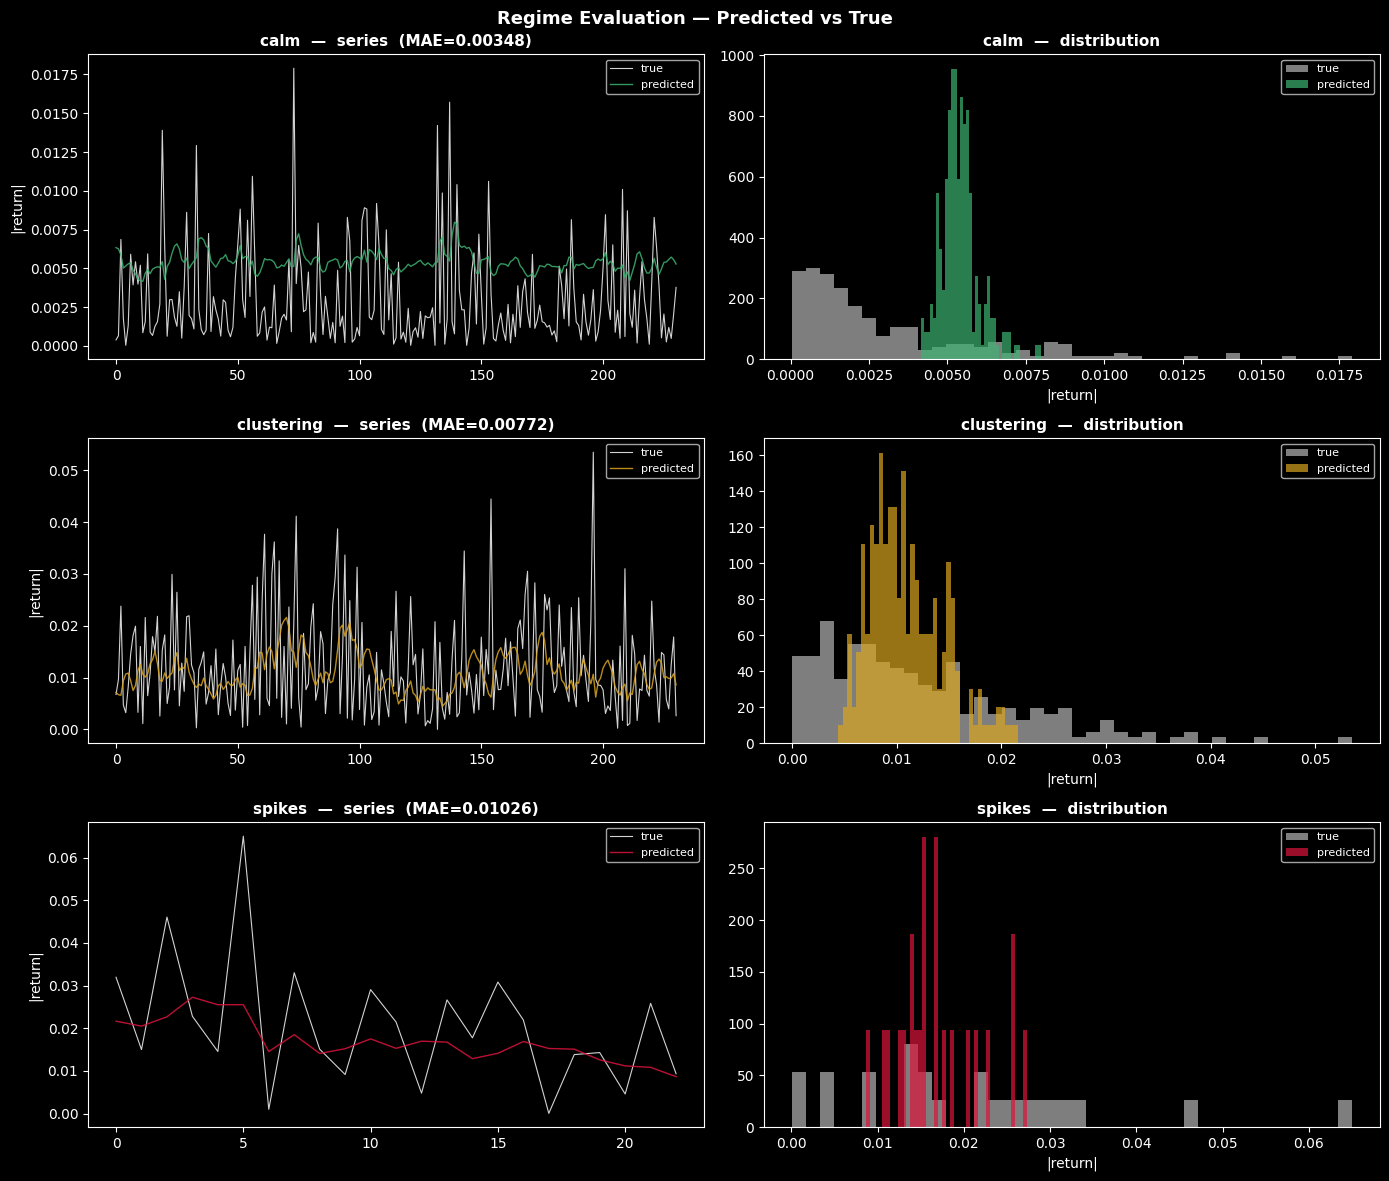

            n_days       MAE
regime                      
calm           231  0.003479
clustering     231  0.007715
spikes          23  0.010260


In [9]:
regime_results = evaluate_regimes(trainer, regime_sets, scaler_y)

## Grid Search — Find the Best Architecture

Runs all combinations of the param grid with a light training budget (80 epochs, early stopping 15). Results are sorted by val MAE. Use the top config to build the final model before running the deep analysis above.

In [10]:
#grid_results = grid_search_rnn(df, test_df)
#grid_results.to_csv('grid_results.csv')
df_results = pd.read_csv('grid_results.csv', index_col=0)
df_results.head()

,rank,sequence_length,hidden_size,num_layers,lr,grad_clip,val_MAE,MAE_calm,MAE_clustering,MAE_spikes
0,1,20,64,1,0.0005,0.5,0.004219,0.002860,0.008079,0.009979
1,2,30,64,2,0.0010,0.5,0.004228,0.002948,0.007597,0.008271
2,3,20,32,2,0.0005,1.0,0.004229,0.002763,0.007710,0.010274
3,4,10,64,2,0.0010,0.5,0.004238,0.002633,0.007917,0.015570
4,5,30,32,1,0.0005,0.5,0.004242,0.003222,0.007692,0.007998


# Analysis Roadmap

The sections below lay out the full analysis pipeline from this baseline to advanced RNN architectures. Each section has a clear goal and a concrete output. Work through them in order.

## Step 1 — Understand What the Model Actually Learned

Before tuning anything, understand the current model.

**1.1 — Weight inspection**
Plot the distribution of the RNN input weights (`W_ih`), hidden-to-hidden weights (`W_hh`), and head weights. Healthy weights should be roughly zero-centred with moderate spread. Dead weights (all near zero) or exploding weights (very large magnitude) are red flags.

**1.2 — Hidden state analysis**
Run inference and collect the hidden state `h_t` at each time step. Plot it over the test period. Does it react to spikes? Does it return to baseline after a calm period? This shows you what the RNN is actually "remembering".

**1.3 — Input sensitivity**
For each position in the sequence (lag 1 to lag N), measure how much changing that input moves the prediction. A well-functioning RNN should be most sensitive to recent lags — if it is equally sensitive to all lags, the hidden state is not doing its job.

**Expected output:** a qualitative understanding of whether the model is actually exploiting the sequential structure or behaving like a simple weighted average.

### 1.1 — Weight Distributions

**What to look for:**
- `W_ih` (input → hidden): how the model reads new data at each step. Healthy = spread around 0. Dead = everything near 0 (model ignores input).
- `W_hh` (hidden → hidden): the memory matrix. This is the one that causes vanishing gradients when its values are too small. A narrow distribution centred at 0 means the hidden state barely propagates information across steps.
- `Head` (hidden → output): how the final prediction is formed. Should also be spread, not dead.

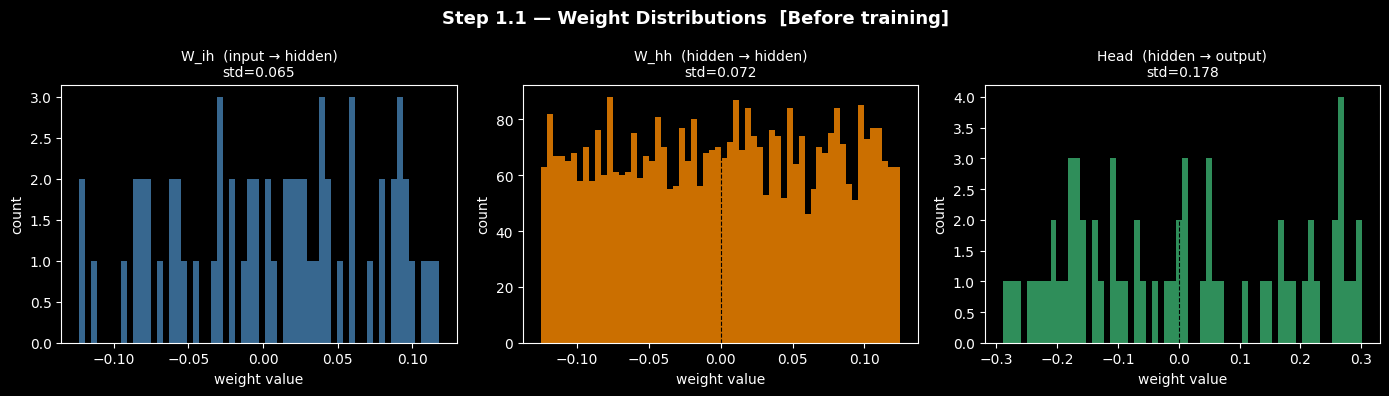

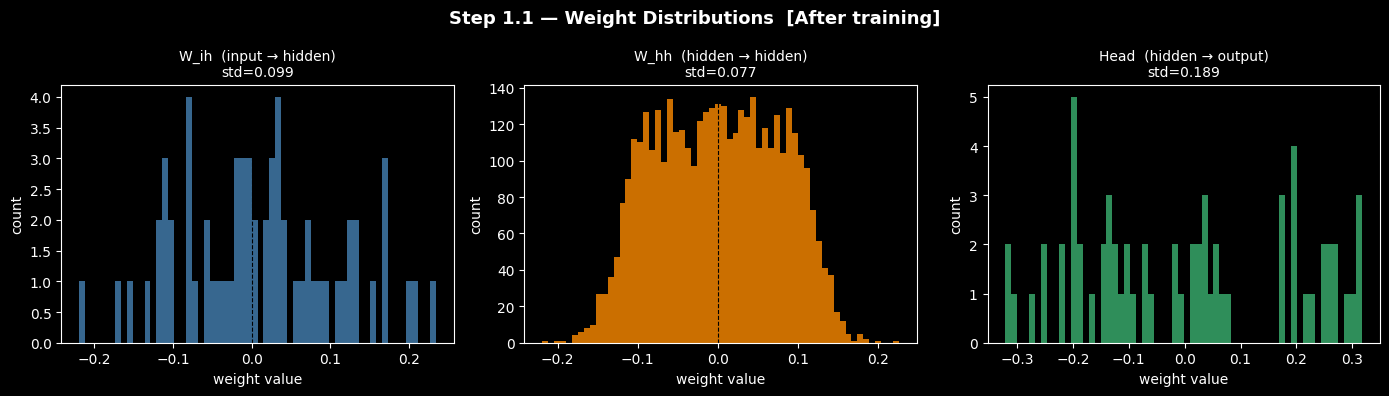

In [11]:
plot_weight_distributions(Rnn_before, title="Before training")
plot_weight_distributions(Rnn_simple, title="After training")

### 1.2 — Hidden State Activity Over Time

**What to look for:**
- The orange line is the average activation level of the hidden state across the sequence positions (0 = oldest input, T = most recent).
- **Good**: activity rises when the model processes volatile periods — the memory is engaged.
- **Bad**: flat line — the hidden state is barely changing, meaning the model is not accumulating useful context. It is essentially ignoring the sequence structure.

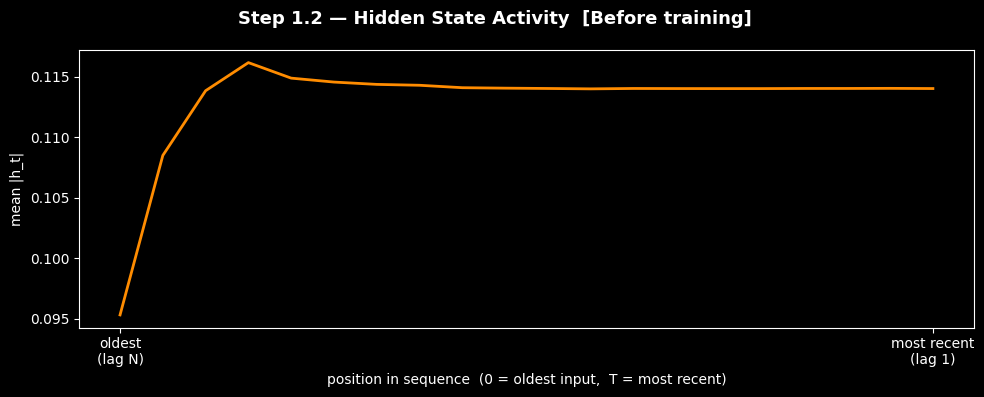

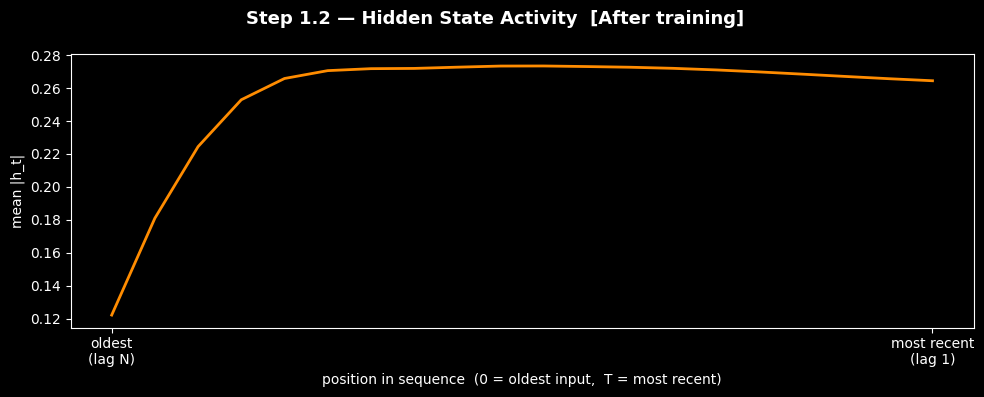

In [14]:
plot_hidden_state_activity(Rnn_before, X_val, title="Before training")
plot_hidden_state_activity(Rnn_simple, X_val, title="After training")

### 1.3 — Input Sensitivity by Lag

**What to look for:**
- Each bar is a lag position. Lag 1 = yesterday, lag N = N days ago.
- The height of each bar = how much changing that day's return affects today's prediction on average.
- **Good**: bars decrease smoothly from lag 1 (tallest) to lag N (shortest). The model uses recent data most, older data less — which makes sense.
- **Vanishing gradient**: bars drop to near zero after ~5-10 lags. The model only uses the last few days no matter how long the sequence is — extending `SEQUENCE_LENGTH` won't help.
- **Flat**: all bars roughly equal height. The model is treating all lags the same, not exploiting temporal order.

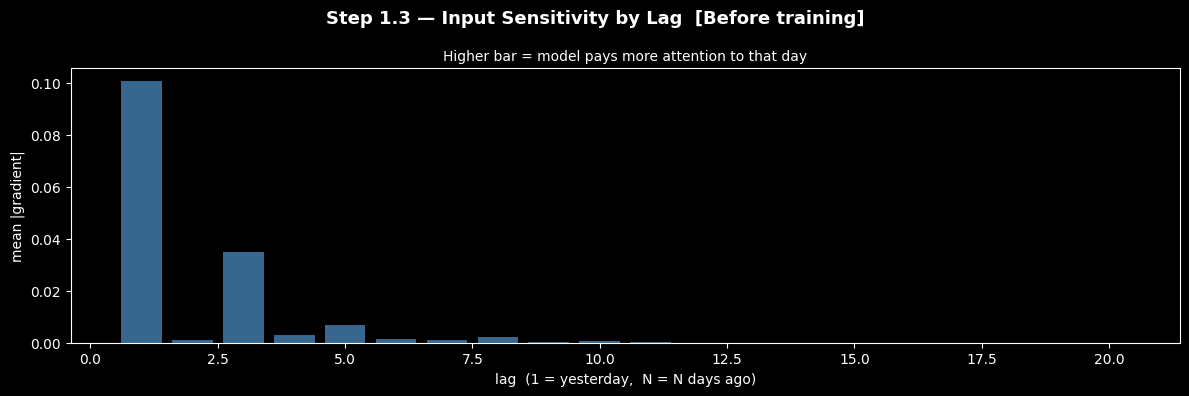

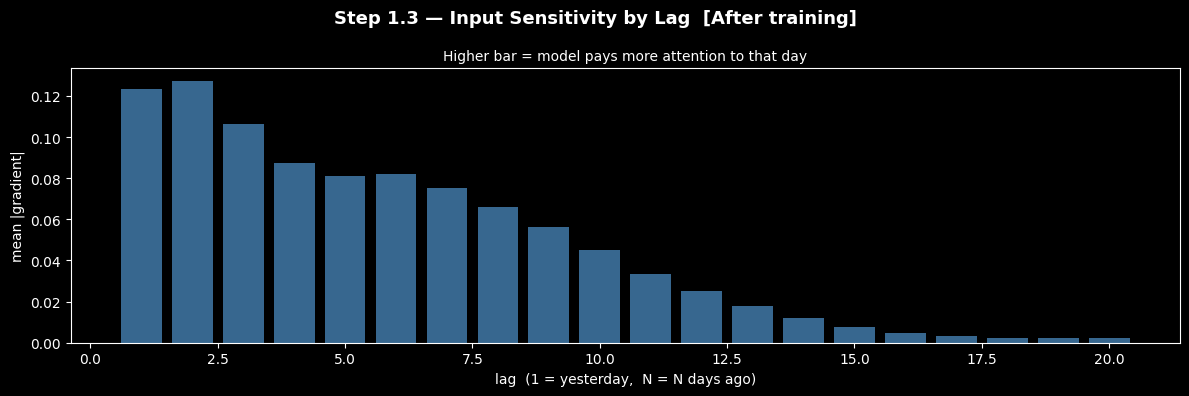

In [15]:
plot_input_sensitivity(Rnn_before, X_val, title="Before training")
plot_input_sensitivity(Rnn_simple, X_val, title="After training")

## Step 2 — Error Analysis

Understand where and when the model fails, not just the average MAE.

**2.1 — Residual plot over time**
Plot `|error_t| = |y_true_t - y_pred_t|` over the test period. Do errors spike during high-volatility periods? This would confirm the model underestimates extreme moves.

**2.2 — Error vs magnitude**
Scatter plot of `y_true` vs `error`. If the model is regressing toward the mean, errors grow linearly with the true value. This is the most common failure mode.

**2.3 — Per-regime error breakdown**
Already done via `evaluate_regimes` — but go deeper. Look at the worst 5% of predictions in each regime. What did the input sequence look like just before those failures?

**Expected output:** a precise diagnosis — is the model bad everywhere, or specifically bad on spikes/transitions?

## Step 3 — Vanishing Gradient Diagnosis

The vanilla RNN propagates gradients backward through time via repeated multiplication by `W_hh`. If any singular value of `W_hh` is < 1, gradients shrink exponentially as they travel back — the network effectively forgets anything beyond ~10-20 steps even if you give it a sequence of 60.

This is not a bug, it is a structural property. But you need to measure how bad it is before tuning sequence length or moving to LSTM.

**3.1 — Gradient norm per time step**
During a backward pass, record the norm of the gradient with respect to the hidden state `h_t` at each step `t`. Plot these norms from `t=T` back to `t=0`. If they collapse to near zero after ~10 steps, the model has no usable memory beyond that point — extending `SEQUENCE_LENGTH` beyond that threshold is pointless.

**3.2 — Effective memory length**
Measure the correlation between the final hidden state `h_T` and each input `x_t` for `t = T, T-1, ..., 1`. This shows empirically how many steps back the model is actually paying attention to.

**3.3 — `W_hh` spectrum**
Plot the singular values of the hidden-to-hidden weight matrix `W_hh`. Values consistently below 1 confirm gradient shrinkage; values above 1 indicate exploding gradients. The spectral radius (largest singular value) tells you whether the RNN is in a stable, vanishing, or exploding regime.

**Expected output:** a concrete number — "this RNN effectively remembers the last N steps" — which directly motivates the sequence length choice and the move to LSTM/GRU.

---
*Note: steps 3, 4, 5 below were originally numbered 3, 4 — they are now renumbered to account for this section.*

## Step 4 — Hyperparameter Search

Now that you know what the model does, where it fails, and how far its memory actually reaches, tune systematically. Change **one thing at a time** and record the result.

**4.1 — Sequence length** (`SEQUENCE_LENGTH`)
Try 10, 20, 30, 60 — but only up to the effective memory length found in Step 3. Beyond that threshold, longer sequences add no signal and increase training time.

**4.2 — Hidden size** (`HIDDEN_SIZE`)
Try 32, 64, 128. More units = more memory capacity. Watch the train/val gap — if it widens, you are overfitting.

**4.3 — Learning rate**
Try 0.01, 0.001, 0.0001. Also try a cosine decay schedule. The learning rate is often the single biggest lever.

**4.4 — Gradient clipping**
Try 0.5, 1.0, 5.0, None. Too tight and the model learns slowly; too loose and training is unstable. Watch the loss curve shape.

**4.5 — Dropout on the head**
Light dropout (0.1–0.2) on the Dense head can reduce overfitting without hurting the recurrent part.

**Expected output:** a table of (config → val MAE → regime MAEs) that shows which knobs actually move the needle.